In [1]:
import torch
import torchvision
from lexplainet.implicit.rules import *

device = "cuda" if torch.cuda.is_available() else "cpu"

def model_loader(model_name, device):
    if model_name == "resnet18":
        model = torchvision.models.resnet18(pretrained=True)
    elif model_name == "resnet34":
        model = torchvision.models.resnet34(pretrained=True)
    elif model_name == "resnet50":
        model = torchvision.models.resnet50(pretrained=True)
    else:
        raise ValueError("Unsupported model name")
    
    model = model.to(device)
    model.device = device
    model.eval()
    return model

model = model_loader("resnet18", device)

/home/erfan/miniconda3/envs/lrp_exercise/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/erfan/miniconda3/envs/lrp_exercise/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

from imagenet import IMAGENET_CLASS_NAMES
from imagenet.utils import inference_transform
from lexplainet.heatmap import show_image, load_image, plot_heatmap



Image Tensor Shape: torch.Size([1, 3, 224, 224])


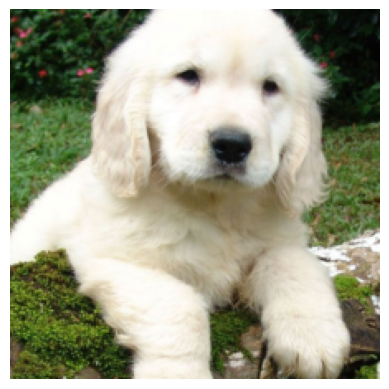

<Figure size 640x480 with 0 Axes>

In [3]:
image_tensor = load_image('./dog_1.png', transform=inference_transform, device=device)
show_image(image_tensor, transform=inference_transform)

In [4]:
from model_utils.inference import inference, forward_pass
from model_utils.autograd import explain_model_prediction, make_gradient_output

In [ ]:
from lexplainet.implicit.model_specific_patches import canonize_resnet
from lexplainet.implicit.core import patch_composite
from lexplainet.implicit.rules import gamma_rule, identity_rule, epsilon_rule

composite = {
            torch.nn.Conv2d: (gamma_rule, {'gamma': 1000.}), 
            torch.nn.ReLU: (identity_rule, {}),
            torch.nn.BatchNorm2d: (identity_rule, {}),
            torch.nn.Linear: (epsilon_rule, {})
}

canonize_resnet(model)
patch_composite(model, composite)

/home/erfan/miniconda3/envs/lrp_exercise/lib/python3.10/site-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


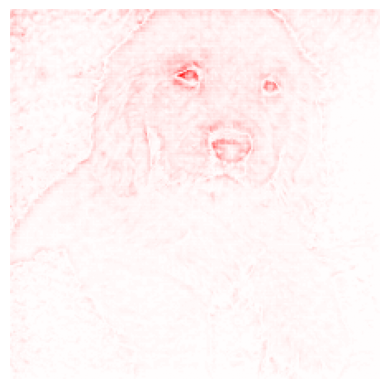

In [6]:
image_tensor.requires_grad = True

output = forward_pass(model, image_tensor, gradient_required=True)
predicted_class = output.argmax(dim=1).item()

gradient_output = make_gradient_output(output, predicted_class)
output.backward(gradient_output)

relevance = image_tensor.grad.detach().cpu() * image_tensor.detach().cpu()
lrp_normalized_relevance = (relevance / torch.max(torch.abs(relevance))).sum(dim=1)
plot_heatmap(lrp_normalized_relevance, save=True, save_path="resnet18_lrp_heatmap_dog_1.png")

Image Tensor Shape: torch.Size([1, 3, 224, 224])


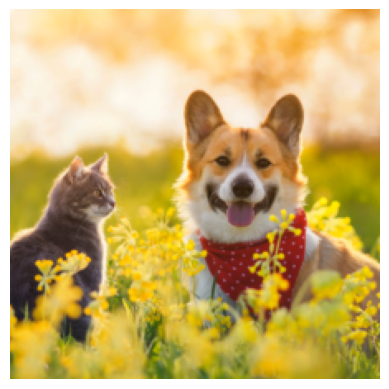

<Figure size 640x480 with 0 Axes>

In [13]:
image_tensor = load_image('./dog_2.png', transform=inference_transform, device=device)
show_image(image_tensor, transform=inference_transform)

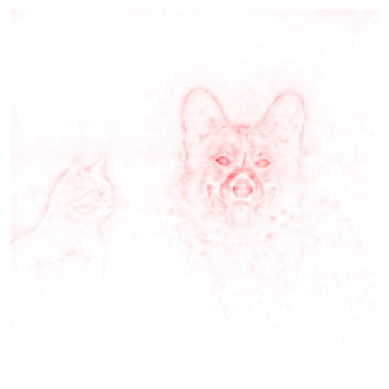

In [15]:
image_tensor.requires_grad = True

output = forward_pass(model, image_tensor, gradient_required=True)
predicted_class = output.argmax(dim=1).item()

gradient_output = make_gradient_output(output, predicted_class)
output.backward(gradient_output)

relevance = image_tensor.grad.detach().cpu() * image_tensor.detach().cpu()
lrp_normalized_relevance = (relevance / torch.max(torch.abs(relevance))).sum(dim=1)
plot_heatmap(lrp_normalized_relevance)

In [ ]:
heatmapplot_heatmap(lrp_normalized_relevance, show=False)

(array([[0.0271997 , 0.04009883, 0.04685914, ..., 0.01784864, 0.01945923,
         0.01004786],
        [0.04093734, 0.05492827, 0.04506358, ..., 0.02904896, 0.02216314,
         0.0161771 ],
        [0.0374063 , 0.04088292, 0.03513223, ..., 0.0300894 , 0.01537945,
         0.01407387],
        ...,
        [0.00037221, 0.00065318, 0.00109261, ..., 0.0019915 , 0.00246099,
         0.00188712],
        [0.00030078, 0.00054077, 0.00075382, ..., 0.00074655, 0.00089435,
         0.00064578],
        [0.00036617, 0.00029414, 0.00053735, ..., 0.00044872, 0.00044393,
         0.00026635]], shape=(224, 224), dtype=float32),
 np.float32(2.2186995))